# Lab: Classifier Evaluation

**BINF 6210/8210 - Machine Learning for Bioinformatics**
___

## Learning objectives

**Goal:** implement an end-to-end binary-classification workflow using logistic regression.

We will use the **Breast Cancer Wisconsin** dataset bundled with scikit-learn and demonstrate:

1. Train/development vs. test split
2. A leakage-safe `Pipeline` with `StandardScaler` and logistic regression
3. Stratified cross-validation
4. Hyperparameter tuning
5. Out-of-fold (OOF) predictions on the development data
6. ROC and precision–recall (PR) curves
7. Threshold selection **using development data only**
8. Refit the final model on all development data
9. One-time evaluation on the untouched test set
10. Confusion matrix and threshold-dependent metrics
11. Bootstrap confidence intervals on the test set

> **Central principle:** the test set is not used to select preprocessing, hyperparameters, the model, or the classification threshold. It is reserved for final evaluation.


## 1. Imports and reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 2. Load the dataset

For this dataset, scikit-learn originally codes malignant as `0` and benign as `1`. To make the medically important outcome the positive class, we recode:

- `1` = malignant
- `0` = benign


In [7]:
# Load and explore the data

data = load_breast_cancer(as_frame=True)

X = data.data.copy()
y = (data.target == 0).astype(int) # recode malignant = 1 and benign = 0
y.name = "malignant"

print("X shape:", X.shape)
print("\nClass counts:")
print(y.value_counts())

print("\nClass proportions:")
print(y.value_counts(normalize=True))


X shape: (569, 30)

Class counts:
malignant
0    357
1    212
Name: count, dtype: int64

Class proportions:
malignant
0    0.627417
1    0.372583
Name: proportion, dtype: float64


## 3. Create development and test sets

We reserve **20%** of the data as an untouched test set. The remaining **80%** is the development set.

`stratify=y` approximately preserves the class distribution in both subsets.

The test set should now be conceptually **locked away** until the model and threshold have been finalized.


In [8]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Development samples:", len(X_dev))
print("Test samples:", len(X_test))

print("\nDevelopment class proportions:")
print(y_dev.value_counts(normalize=True))


print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))


Development samples: 455
Test samples: 114

Development class proportions:
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test class proportions:
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## 4. Construct a leakage-safe pipeline

Standardization is part of the pipeline rather than being applied to the complete dataset beforehand.

During cross-validation, `StandardScaler` is therefore fitted **only on the training folds**. The validation fold is transformed using the mean and standard deviation learned from those training folds.

This prevents preprocessing leakage.
___
Break down of the Pipeline grammar:
- The List []: houses the entire sequence of operations. The data will flow through these steps in order, from top to bottom.
- The Tuples (): Each step in the pipeline is defined as a pair containing exactly two elements: ("name", estimator).
    - The Name (String): A user-defined label, like "scaler" or "logreg". This allows you to reference, inspect, or tune the parameters of that specific step later.
    - The Estimator (Object): The actual scikit-learn class instance that performs the work (like `StandardScaler()` or `LogisticRegression()`).

In [9]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (mu

## 5. Define stratified cross-validation

For binary biomedical outcomes, `StratifiedKFold` helps preserve the positive/negative class proportions across folds.


In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## 6. Hyperparameter tuning using the development data only

For logistic regression we tune:

- `C`: inverse regularization strength
- `l1_ratio`: `0.0` for L2 regularization versus `1.0` for L1 regularization

Smaller `C` means **stronger regularization**.

We use mean cross-validated **AUROC** as the hyperparameter-selection criterion.

Importantly, the test set does not participate in this search.


### Current scikit-learn regularization API

This notebook uses `l1_ratio` rather than the deprecated `penalty` argument:

- `l1_ratio = 0.0` corresponds to **L2** regularization.
- `l1_ratio = 1.0` corresponds to **L1** regularization.
- Values strictly between 0 and 1 represent mixtures of L1 and L2 regularization when supported by the solver.

Here we compare the two endpoints, L2 and L1, while tuning `C`.


In [12]:
param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logreg__l1_ratio": [0.0, 1.0]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    refit=True
)

grid.fit(X_dev, y_dev)

print("Best parameters:", grid.best_params_)
print(f"Best mean CV AUROC: {grid.best_score_:.3f}")


Best parameters: {'logreg__C': 1, 'logreg__l1_ratio': 1.0}
Best mean CV AUROC: 0.996


### Examine all hyperparameter combinations

In [13]:
cv_results = (
    pd.DataFrame(grid.cv_results_)
    [["param_logreg__C", "param_logreg__l1_ratio",
      "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

cv_results


,param_logreg__C,param_logreg__l1_ratio,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,1.000,1.0,0.997762,0.995872,0.004102,1
1,1.000,0.0,0.997710,0.995872,0.004650,2
2,0.100,0.0,0.995898,0.994840,0.005624,3
3,10.000,0.0,0.999645,0.994427,0.003908,4
4,0.010,0.0,0.993041,0.991950,0.008356,5
5,100.000,0.0,0.999987,0.991847,0.004247,6
6,0.100,1.0,0.993589,0.991331,0.007108,7
7,10.000,1.0,0.999910,0.991022,0.004858,8
8,100.000,1.0,1.000000,0.988442,0.006850,9
9,0.001,0.0,0.986765,0.985862,0.010323,10


## 7. Obtain out-of-fold probabilities for the selected model

`GridSearchCV` identified the hyperparameters using cross-validation. We now generate **out-of-fold (OOF)** predicted probabilities across the development set using the selected pipeline.

For each development sample, its OOF probability comes from a model that was trained **without that sample**.

We will use these development-set OOF predictions to:

- visualize ROC and PR performance;
- select a classification threshold.

### Important methodological note

Because the same development data were already used for hyperparameter selection, this OOF analysis is primarily part of **model development**, not the final unbiased performance claim. For a small dataset where no independent test set is available, **nested cross-validation** is preferable for an unbiased internal performance estimate.


In [14]:
best_params = grid.best_params_

selected_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=RANDOM_STATE,
        C=best_params["logreg__C"],
        l1_ratio=best_params["logreg__l1_ratio"]
    ))
])

dev_oof_prob = cross_val_predict(
    selected_pipe,
    X_dev,
    y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

dev_auc = roc_auc_score(y_dev, dev_oof_prob)
dev_ap = average_precision_score(y_dev, dev_oof_prob)

print(f"Development OOF AUROC: {dev_auc:.3f}")
print(f"Development OOF Average Precision: {dev_ap:.3f}")


Development OOF AUROC: 0.995
Development OOF Average Precision: 0.994


## 8. Plot ROC and PR curves on development OOF predictions

These curves evaluate the model's probability ranking across many possible thresholds.

- ROC curve: sensitivity (TPR) versus false-positive rate (FPR)
- PR curve: precision versus recall


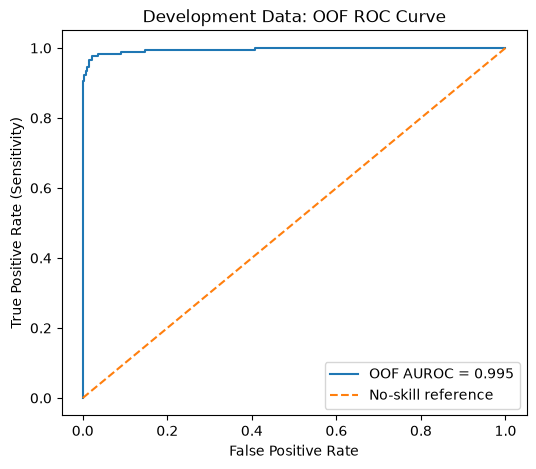

In [15]:
fpr_dev, tpr_dev, roc_thresholds_dev = roc_curve(y_dev, dev_oof_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_dev, tpr_dev, label=f"OOF AUROC = {dev_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill reference")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Development Data: OOF ROC Curve")
plt.legend()
plt.show()


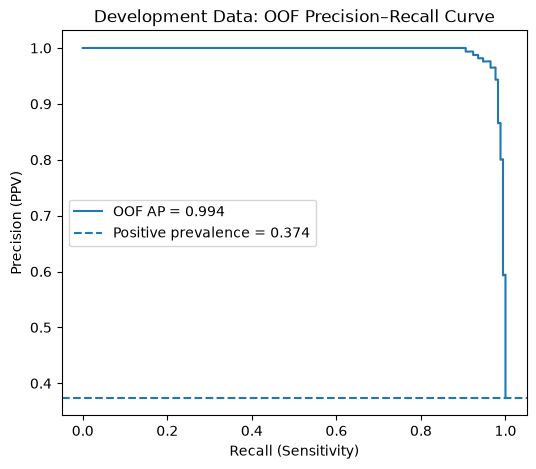

In [16]:
precision_dev, recall_dev, pr_thresholds_dev = precision_recall_curve(
    y_dev, dev_oof_prob
)

baseline = y_dev.mean()

plt.figure(figsize=(6, 5))
plt.plot(recall_dev, precision_dev, label=f"OOF AP = {dev_ap:.3f}")
plt.axhline(baseline, linestyle="--",
            label=f"Positive prevalence = {baseline:.3f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Development Data: OOF Precision–Recall Curve")
plt.legend()
plt.show()


## 9. Select a classification threshold using development data

A threshold should be chosen according to the scientific/clinical objective—not by looking at the test set.

For demonstration, suppose the requirement is:

> **Achieve sensitivity of at least 90%, then choose the threshold with the highest specificity among thresholds satisfying that requirement.**

This is only an example. In a real application, the threshold-selection rule should reflect the relative consequences of false negatives and false positives.

We compute candidate thresholds from the OOF development predictions.


In [17]:
def threshold_table(y_true, y_prob, thresholds):
    rows = []

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else np.nan

        rows.append({
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "accuracy": (tp + tn) / (tp + tn + fp + fn),
            "TP": tp, "FP": fp, "TN": tn, "FN": fn
        })

    return pd.DataFrame(rows)

candidate_thresholds = np.linspace(0.01, 0.99, 99)

threshold_results = threshold_table(
    y_dev.to_numpy(),
    dev_oof_prob,
    candidate_thresholds
)

eligible = threshold_results[
    threshold_results["sensitivity"] >= 0.90
].copy()

chosen_row = eligible.sort_values(
    ["specificity", "threshold"],
    ascending=[False, False]
).iloc[0]

chosen_threshold = float(chosen_row["threshold"])

print(f"Chosen threshold: {chosen_threshold:.2f}")
chosen_row.to_frame("value")


Chosen threshold: 0.82


,value
threshold,0.820000
sensitivity,0.900000
specificity,1.000000
precision,1.000000
accuracy,0.962637
TP,153.000000
FP,0.000000
TN,285.000000
FN,17.000000


### Visualize the threshold trade-off

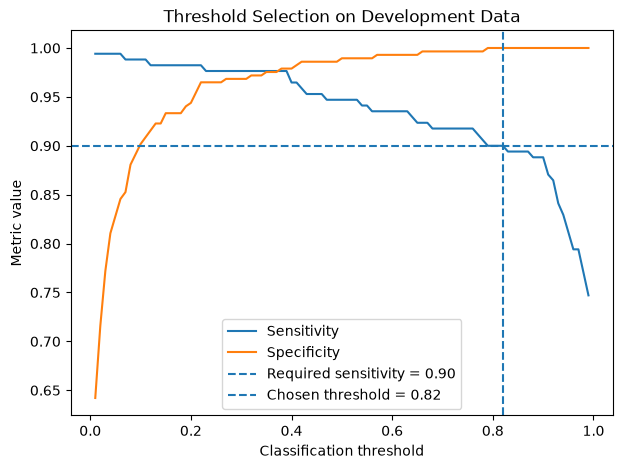

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_results["threshold"],
         threshold_results["sensitivity"],
         label="Sensitivity")
plt.plot(threshold_results["threshold"],
         threshold_results["specificity"],
         label="Specificity")
plt.axhline(0.90, linestyle="--", label="Required sensitivity = 0.90")
plt.axvline(chosen_threshold, linestyle="--",
            label=f"Chosen threshold = {chosen_threshold:.2f}")
plt.xlabel("Classification threshold")
plt.ylabel("Metric value")
plt.title("Threshold Selection on Development Data")
plt.legend()
plt.show()


## 10. Refit the finalized model on ALL development data

At this point we have frozen:

- preprocessing;
- model type;
- hyperparameters;
- threshold-selection rule;
- final threshold.

We can now fit the selected pipeline using all development samples.


In [19]:
final_model = selected_pipe.fit(X_dev, y_dev)

print(final_model)


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=1, l1_ratio=1.0, max_iter=5000,
                                    random_state=42, solver='liblinear'))])


### Inspect scaler statistics and logistic-regression coefficients

Because the scaler is inside the fitted pipeline, we can retrieve its learned feature means and standard deviations.

The logistic-regression coefficients correspond to **standardized predictor values**.


In [20]:
scaler = final_model.named_steps["scaler"]
logreg = final_model.named_steps["logreg"]

model_details = pd.DataFrame({
    "feature": X_dev.columns,
    "training_mean": scaler.mean_,
    "training_sd": scaler.scale_,
    "coefficient": logreg.coef_[0]
})

model_details["odds_ratio_per_1_SD"] = np.exp(model_details["coefficient"])

model_details.sort_values(
    "coefficient",
    key=lambda s: s.abs(),
    ascending=False
).head(10)


,feature,training_mean,training_sd,coefficient,odds_ratio_per_1_SD
10,radius error,0.411187,0.289864,2.667882,14.409416
23,worst area,890.569231,581.705888,2.084853,8.043410
21,worst texture,25.904879,6.072847,2.075131,7.965588
7,mean concave points,0.049015,0.039642,1.919636,6.818478
20,worst radius,16.351514,4.895648,1.624458,5.075666
26,worst concavity,0.275166,0.211833,1.099528,3.002750
15,compactness error,0.025323,0.017605,-1.005521,0.365854
11,texture error,1.217882,0.551705,-0.688288,0.502436
28,worst symmetry,0.291364,0.062974,0.659642,1.934101
14,smoothness error,0.006895,0.002851,0.324553,1.383412


## 11. Final evaluation on the untouched test set

This is the first time the test outcomes are used for evaluation.

We first obtain predicted probabilities. These probabilities support threshold-independent analyses such as ROC/AUROC and PR/AP.


In [21]:
test_prob = final_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)

print(f"Test AUROC: {test_auc:.3f}")
print(f"Test Average Precision: {test_ap:.3f}")


Test AUROC: 0.996
Test Average Precision: 0.994


## 12. Test-set ROC curve

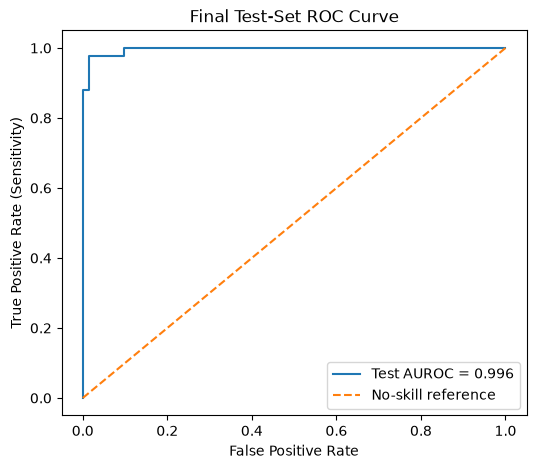

In [22]:
fpr_test, tpr_test, _ = roc_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_test, tpr_test, label=f"Test AUROC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill reference")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Final Test-Set ROC Curve")
plt.legend()
plt.show()


## 13. Test-set precision–recall curve

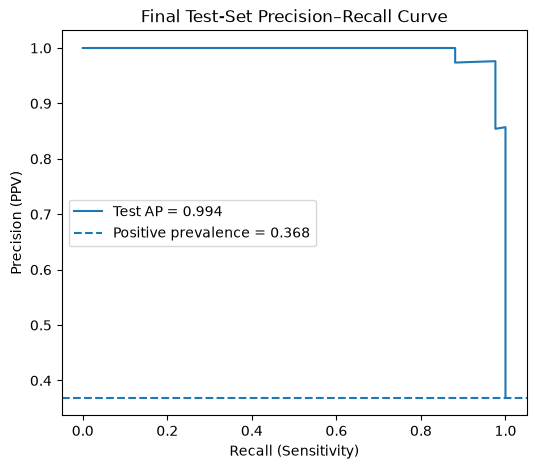

In [23]:
precision_test, recall_test, _ = precision_recall_curve(y_test, test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_test, precision_test, label=f"Test AP = {test_ap:.3f}")
plt.axhline(y_test.mean(), linestyle="--",
            label=f"Positive prevalence = {y_test.mean():.3f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Final Test-Set Precision–Recall Curve")
plt.legend()
plt.show()


## 14. Apply the PRESELECTED threshold to the test set

We do **not** optimize the threshold using test outcomes.

The threshold selected from development data is applied unchanged.


In [24]:
test_pred = (test_prob >= chosen_threshold).astype(int)

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
cm


array([[72,  0],
       [ 7, 35]])

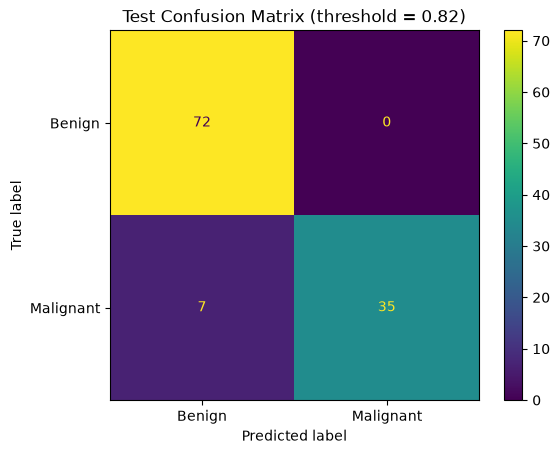

In [25]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
).plot()

plt.title(f"Test Confusion Matrix (threshold = {chosen_threshold:.2f})")
plt.show()


## 15. Calculate threshold-dependent test metrics

In [26]:
def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Sensitivity / Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "Precision / PPV": precision_score(y_true, y_pred, zero_division=0),
        "NPV": tn / (tn + fn) if (tn + fn) else np.nan,
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

test_metrics = classification_metrics(y_test, test_pred)

pd.Series(test_metrics, name="Test performance").to_frame()


,Test performance
Accuracy,0.938596
Sensitivity / Recall,0.833333
Specificity,1.000000
Precision / PPV,1.000000
NPV,0.911392
F1,0.909091


## 16. Bootstrap confidence intervals on the test set

A point estimate such as AUROC = 0.95 does not tell us how uncertain that estimate is.

We therefore bootstrap **test observations** with replacement.

For each bootstrap sample we calculate:

- AUROC
- Average Precision (AP)
- Accuracy
- Sensitivity
- Specificity
- Precision
- F1

The fitted model and the threshold remain fixed. We are estimating uncertainty in the performance of the already-finalized classifier.

Bootstrap samples containing only one outcome class are skipped because AUROC is undefined in that situation.


In [27]:
def bootstrap_test_metrics(
    y_true,
    y_prob,
    threshold,
    n_boot=2000,
    random_state=42
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    rng = np.random.default_rng(random_state)
    rows = []

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)

        y_b = y_true[idx]
        p_b = y_prob[idx]

        if np.unique(y_b).size < 2:
            continue

        pred_b = (p_b >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_b, pred_b, labels=[0, 1]
        ).ravel()

        rows.append({
            "AUROC": roc_auc_score(y_b, p_b),
            "Average Precision": average_precision_score(y_b, p_b),
            "Accuracy": accuracy_score(y_b, pred_b),
            "Sensitivity": recall_score(y_b, pred_b, zero_division=0),
            "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "Precision": precision_score(y_b, pred_b, zero_division=0),
            "F1": f1_score(y_b, pred_b, zero_division=0)
        })

    return pd.DataFrame(rows)

boot = bootstrap_test_metrics(
    y_test,
    test_prob,
    chosen_threshold,
    n_boot=2000,
    random_state=RANDOM_STATE
)

boot.shape


(2000, 7)

### Construct percentile 95% bootstrap confidence intervals

In [28]:
point_estimates = {
    "AUROC": test_auc,
    "Average Precision": test_ap,
    "Accuracy": test_metrics["Accuracy"],
    "Sensitivity": test_metrics["Sensitivity / Recall"],
    "Specificity": test_metrics["Specificity"],
    "Precision": test_metrics["Precision / PPV"],
    "F1": test_metrics["F1"]
}

summary_rows = []

for metric, point in point_estimates.items():
    lower, upper = boot[metric].quantile([0.025, 0.975])

    summary_rows.append({
        "Metric": metric,
        "Point estimate": point,
        "95% CI lower": lower,
        "95% CI upper": upper
    })

bootstrap_summary = pd.DataFrame(summary_rows)
bootstrap_summary


,Metric,Point estimate,95% CI lower,95% CI upper
0,AUROC,0.996362,0.988959,1.000000
1,Average Precision,0.994245,0.981528,1.000000
2,Accuracy,0.938596,0.894518,0.982456
3,Sensitivity,0.833333,0.714206,0.941205
4,Specificity,1.000000,1.000000,1.000000
5,Precision,1.000000,1.000000,1.000000
6,F1,0.909091,0.833279,0.969712


### Visualize one bootstrap distribution: AUROC

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(boot["AUROC"], bins=30)
plt.axvline(test_auc, linestyle="--",
            label=f"Observed AUROC = {test_auc:.3f}")

ci_low, ci_high = boot["AUROC"].quantile([0.025, 0.975])
plt.axvline(ci_low, linestyle=":")
plt.axvline(ci_high, linestyle=":")

plt.xlabel("AUROC")
plt.ylabel("Bootstrap frequency")
plt.title("Bootstrap Distribution of Test AUROC")
plt.legend()
plt.show()

print(f"AUROC = {test_auc:.3f} (95% bootstrap CI: {ci_low:.3f}–{ci_high:.3f})")


## 17. Final results table

In [29]:
final_results = bootstrap_summary.copy()

final_results["Estimate (95% CI)"] = final_results.apply(
    lambda r: (
        f'{r["Point estimate"]:.3f} '
        f'({r["95% CI lower"]:.3f}–{r["95% CI upper"]:.3f})'
    ),
    axis=1
)

final_results[["Metric", "Estimate (95% CI)"]]


,Metric,Estimate (95% CI)
0,AUROC,0.996 (0.989–1.000)
1,Average Precision,0.994 (0.982–1.000)
2,Accuracy,0.939 (0.895–0.982)
3,Sensitivity,0.833 (0.714–0.941)
4,Specificity,1.000 (1.000–1.000)
5,Precision,1.000 (1.000–1.000)
6,F1,0.909 (0.833–0.970)


# 18. How the pieces fit together

The notebook implements the following hierarchy:

```text
ALL LABELED DATA
        |
        +-------------------------+
        |                         |
 DEVELOPMENT DATA              TEST DATA
        |                         |
        |                     untouched
        |
 Stratified CV
        |
 Pipeline:
 scaling + logistic regression
        |
 hyperparameter tuning
        |
 selected hyperparameters
        |
 OOF development probabilities
        |
 +---------------------+
 |                     |
ROC / PR         threshold selection
                       |
              freeze threshold
                       |
 Refine/finalize model
        |
 fit on ALL development data
        |
        +-------------------------> TEST DATA
                                      |
                               probabilities
                                      |
                   +------------------+------------------+
                   |                                     |
                ROC / PR                       fixed threshold
             AUROC / AP                                  |
                                                  confusion matrix
                                                        |
                                         sensitivity, specificity,
                                         precision, F1, accuracy
                                                        |
                                              bootstrap test cases
                                                        |
                                                   95% CIs
```

## Three different conceptual layers

### A. Performance metrics
**What aspect of classifier performance are we measuring?**

- AUROC
- AP/AUPRC
- sensitivity
- specificity
- precision
- F1
- accuracy

### B. Validation strategy
**How do we develop the model without evaluating it on the same observations used to fit it?**

- held-out test set
- cross-validation
- nested cross-validation when appropriate

### C. Uncertainty
**How precise are our final performance estimates?**

- bootstrap confidence intervals

Keeping these three layers separate makes the overall evaluation framework much easier to understand.


# 19. Important methodological cautions

### 1. Never tune on the test set
The test set should not determine hyperparameters, feature selection, preprocessing choices, or classification threshold.

### 2. Put learned preprocessing inside the pipeline
This includes standardization, imputation, PCA, and feature-selection procedures that learn from the data.

### 3. Cross-validation is not a metric
It is a **resampling/validation strategy**. AUROC, sensitivity, F1, etc. are performance metrics that can be calculated within cross-validation.

### 4. ROC/PR curves and confusion matrices answer different questions
ROC and PR curves summarize behavior across thresholds. A confusion matrix describes behavior at **one specific threshold**.

### 5. Threshold selection belongs to model development
Choose the threshold using development/validation information and then freeze it before evaluating threshold-dependent metrics on the test set.

### 6. Bootstrap confidence intervals do not replace independent testing
Bootstrapping quantifies uncertainty around the test-set estimates; it does not turn development data into an independent external test set.

### 7. External validation is even stronger
A truly independent cohort from another institution, time period, laboratory, or population provides stronger evidence of generalizability than an internal random test split.
